In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from src.configs.defaults import *
from src.configs.train_config import TrainConfig
from src.utils.set_seed import set_seed
from src.data.utils import load_HandBonesDataset, split_train_val, encode_mask_to_rle, decode_rle_to_mask
from src.data.transforms import get_valid_transform, get_tta_transform
from src.metrics.dice import dice_coef

import json
import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import json

In [2]:
cfg = TrainConfig(
    data_root = TRIAN_ROOT,
    saved_root = SAVED_DIR,
    saved_name="upernet_2048_flip_best.pt",
    split_file_root = "random", # SPLIT_FILE_ROOT,
        
    total=False,
    tta=True,
        
    img_size=2048,
    use_scale=True,
    use_rotate=True,
    use_flip=True,
    use_contrast=True,
        
    model_name='upernet',
    encoder_name='resnext50_32x4d',
    loss_type='BDJ',
    scheduler='warmup',
    optimizer='adam',

    batch_size=2,
    num_workers_train=NUM_WORKERS_TRAIN,
    num_workers_val=NUM_WORKERS_VAL,

    lr=LR,
    num_epochs=NUM_EPOCHS,
    val_every=VAL_EVERY,
    num_patience=NUM_PATIENCE,

    seed=RANDOM_SEED,
        
    use_wandb=False,
)

In [3]:
class XRayValidDataset(Dataset):         # valid 시각화를 위한 dataset
    def __init__(self, cfg):
        
        self.image_root = os.path.join(cfg.data_root, "DCM")
        self.label_root = os.path.join(cfg.data_root, "outputs_json")
        
        pngs, jsons = load_HandBonesDataset(self.image_root, self.label_root)
        
        filenames, labelnames = split_train_val(cfg, pngs, jsons, is_train=False)
        
        self.filenames = filenames
        self.labelnames = labelnames
        self.is_train = False
        self.transforms = get_valid_transform(cfg)
        self.tta_transforms = get_tta_transform() if cfg.tta else None
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, item):
        image_name = self.filenames[item]
        image_path = os.path.join(self.image_root, image_name)
        
        image = cv2.imread(image_path)
        image = image / 255.
        
        label_name = self.labelnames[item]
        label_path = os.path.join(self.label_root, label_name)
        
        # (H, W, NC) 모양의 label을 생성합니다.
        label_shape = tuple(image.shape[:2]) + (len(CLASSES), )
        label = np.zeros(label_shape, dtype=np.uint8)
        
        # label 파일을 읽습니다.
        with open(label_path, "r") as f:
            annotations = json.load(f)
        annotations = annotations["annotations"]
        
        # 클래스 별로 처리합니다.
        for ann in annotations:
            c = ann["label"]
            class_ind = CLASS2IND[c]
            points = np.array(ann["points"])
            
            # polygon 포맷을 dense한 mask 포맷으로 바꿉니다.
            class_label = np.zeros(image.shape[:2], dtype=np.uint8)
            cv2.fillPoly(class_label, [points], 1)
            label[..., class_ind] = class_label
        
        if self.transforms is not None:
            inputs = {"image": image, "mask": label} if self.is_train else {"image": image}
            result = self.transforms(**inputs)
            
            image = result["image"]
            label = result["mask"] if self.is_train else label
        
        if self.tta_transforms is not None:
            tta_result = self.tta_transforms(image=image)
            tta_image = tta_result["image"]

            image = np.stack([image, tta_image], axis=0)
            label = np.stack([label, label], axis=0)
        
        if self.tta_transforms is None:
            image = image.transpose(2, 0, 1)
            label = label.transpose(2, 0, 1)
        else:
            image = image.transpose(0, 3, 1, 2)
            label = label.transpose(0, 3, 1, 2)
        
        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()
            
        return image, image_name, label

In [4]:
def validation(model, data_loader, thr=0.5, tta=False):
    model.eval()
    model = model.cuda()
    
    dices = []
    rles = []
    filename_and_class = []
    
    with torch.no_grad():
        n_class = len(CLASSES)
        for step, (images, image_names, masks) in tqdm(enumerate(data_loader), total=len(data_loader)):
            images, masks = images.cuda(), masks.cuda()         
            
            if not tta:
                if images.shape[-2:] != (2048, 2048):
                    outputs = model(images)
                else:
                    with torch.amp.autocast(device_type="cuda"):
                        outputs = model(images)
                        
            else:
                # 원본 데이터 + TTA 데이터 형태
                if images.dim() == 4 and images.size(0) % 2 == 0:
                    batch_size = images.size(0) // 2
                    images = images.view(batch_size, 2, images.size(1), images.size(2), images.size(3))
                    masks = masks.view(batch_size, 2, masks.size(1), masks.size(2), masks.size(3))
                
                batch_size, n_tta, C, H, W = images.shape            
                outputs_tta = []
                
                for t in range(n_tta):
                    img = images[:, t]
                    
                    if img.shape[-2:] != (2048, 2048):
                        output = model(img)
                    else:
                        with torch.amp.autocast(device_type="cuda"):
                            output = model(img)

                    outputs_tta.append(output)
            
                outputs = torch.stack(outputs_tta, dim=1)
                outputs[:, 1] = torch.flip(outputs[:, 1], dims=[-1])
                outputs = torch.mean(outputs, dim=1)
                masks = masks[:, 0]
            
            output_h, output_w = outputs.size(-2), outputs.size(-1)
            mask_h, mask_w = masks.size(-2), masks.size(-1)
            
            if output_h != mask_h or output_w != mask_w:
                outputs = F.interpolate(outputs, size=(mask_h, mask_w), mode="bilinear")
            
            outputs = torch.sigmoid(outputs)
            outputs = (outputs > thr).float()
            
            dice = dice_coef(masks, outputs)
            dices.append(dice) 
            
            outputs = outputs.cpu().numpy()
            
            for output, image_name in zip(outputs, image_names):
                for c, segm in enumerate(output):
                    rle = encode_mask_to_rle(segm)
                    rles.append(rle)
                    filename_and_class.append(f"{IND2CLASS[c]},{image_name}")
                
    dices = torch.cat(dices, 0)
    dices_per_class = torch.mean(dices, 0)
    
    return dices_per_class, rles, filename_and_class

In [5]:
set_seed(cfg.seed)
    
model = torch.load(os.path.join(cfg.saved_root, cfg.saved_name), weights_only=False)

valid_dataset = XRayValidDataset(cfg)

valid_loader = DataLoader(
    dataset=valid_dataset, 
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers_val,
    drop_last=False
)

dices_per_class, rles, filename_and_class = validation(model, valid_loader, tta=cfg.tta)

classes, filename = zip(*[x.split(",") for x in filename_and_class])
image_name = [os.path.basename(f) for f in filename]
df = pd.DataFrame({
    "image_name": image_name,
    "class": classes,
    "rle": rles,
})

  0%|          | 0/80 [00:00<?, ?it/s]

##

/tmp/ipykernel_2579304/2089654023.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dice_df, x='Dice', y='Class', palette='viridis')


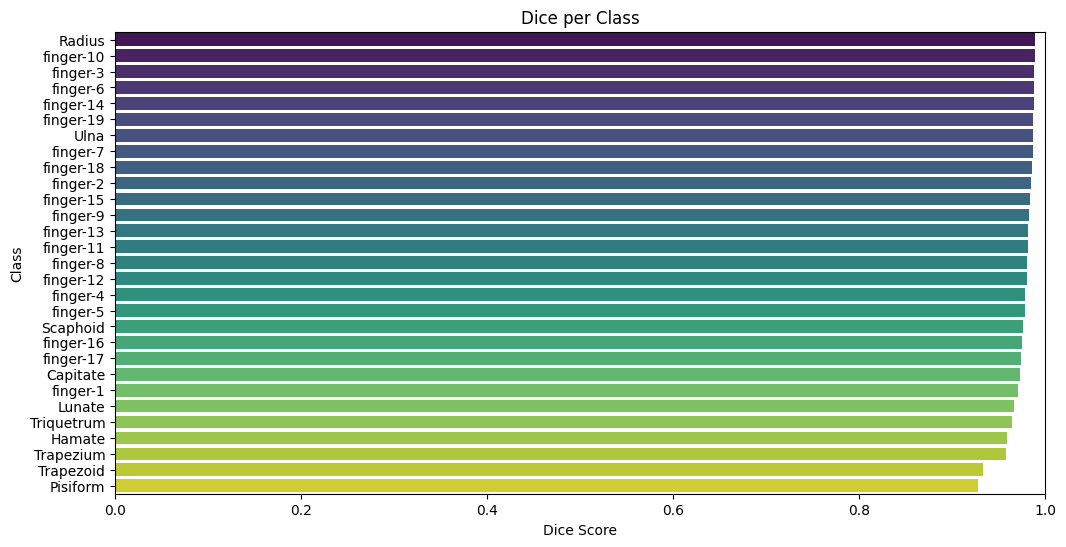

In [7]:
dice_df = pd.DataFrame({
    'Class': CLASSES,
    'Dice': dices_per_class.cpu()
})

dice_df = dice_df.sort_values(by='Dice', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=dice_df, x='Dice', y='Class', palette='viridis')
plt.title('Dice per Class')
plt.xlabel('Dice Score')
plt.ylabel('Class')
plt.xlim(0, 1)
plt.show()

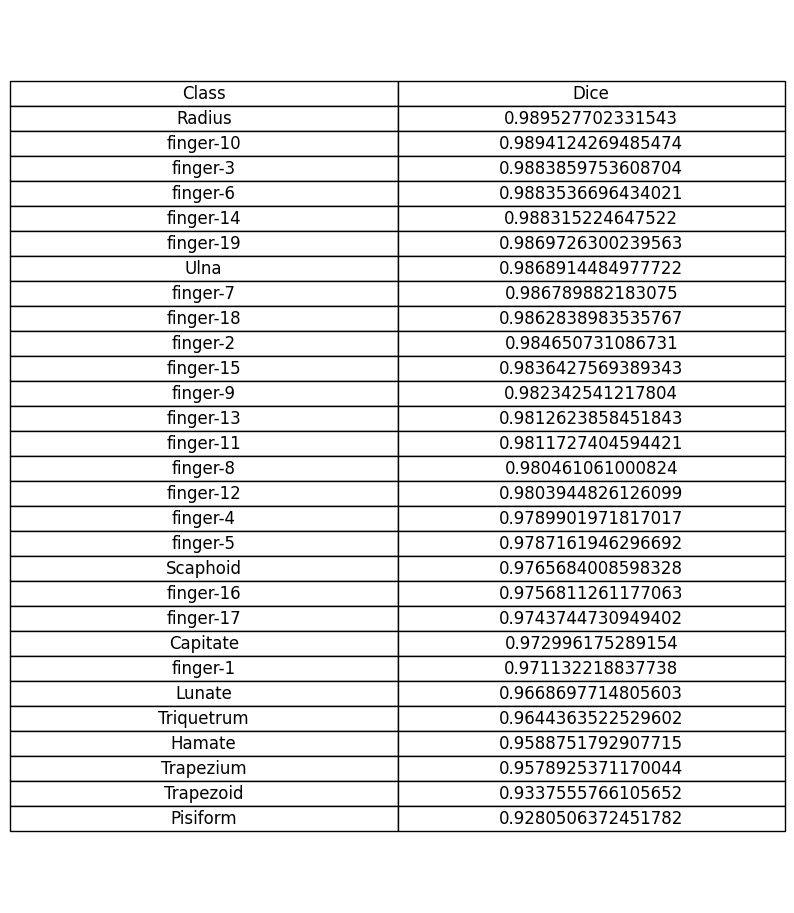

In [8]:
fig, ax = plt.subplots(figsize=(10, len(CLASSES)*0.4))
ax.axis('off')
table = ax.table(
    cellText=dice_df.values,
    colLabels=dice_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)  # 표 크기 조정

plt.show()

In [9]:
def compute_dataset_overlap_dice(df, dataset, decode_rle_to_mask):
    
    overlap_dices = []

    for idx in range(len(dataset)):
        _, image_name, gt_label = dataset[idx]
        if cfg.tta:
            gt_label = gt_label[0] 
        
        H, W = gt_label[0].shape
        C = len(CLASS2IND)

        gt_mask_arr = np.stack([gt_label[class_idx].numpy() for class_idx in range(C)])

        overlap_mask = (gt_mask_arr.sum(axis=0) >= 2)  # GT 기준 overlap 픽셀

        if overlap_mask.sum() == 0:     # 이 이미지에 overlap 픽셀이 없음
            continue

        pred_mask_arr = np.zeros_like(gt_mask_arr)
        for class_name, class_idx in CLASS2IND.items():
            rle_row = df[(df['image_name'] == image_name.split('/')[-1]) & (df['class'] == class_name)]
            if len(rle_row) == 0:
                pred_mask = np.zeros((H, W), dtype=np.uint8)
            else:
                pred_mask = decode_rle_to_mask(rle_row['rle'].values[0], H, W)
            pred_mask_arr[class_idx] = pred_mask

        # overlap 영역만 Dice 계산
        dice_list = []
        for c in range(C):
            gt_c = gt_mask_arr[c] * overlap_mask
            pred_c = pred_mask_arr[c] * overlap_mask

            inter = (gt_c * pred_c).sum()
            denom = gt_c.sum() + pred_c.sum()

            if denom == 0:
                continue

            dice = (2 * inter) / denom
            dice_list.append(dice)

        if len(dice_list) > 0:
            overlap_dices.append(np.mean(dice_list))

    if len(overlap_dices) == 0:
        return None

    return np.mean(overlap_dices)


overall_overlap_dice = compute_dataset_overlap_dice(df, valid_dataset, decode_rle_to_mask)
print(f"Overall Overlap Dice for validation set: {overall_overlap_dice:.4f}")

Overall Overlap Dice for validation set: 0.8432
